# RNN / LSTM / GRU - PAMAP2
## Exploracion y Analisis de Datos (EDA)
**Dataset:** Physical Activity Monitoring
**Sensores:** Mano, Pecho, Tobillo (temperatura, aceleracion, giroscopio, magnetometro)

## Analisis y Preprocesamiento Dataset

Se carga el Dataset para poder mostrar de que se trata y que caracteristicas tiene.

In [ ]:
import pandas as pd
import numpy as np

# Cargamos el dataset
df = pd.read_csv(r'c:\Users\lucia\Desktop\IA 2\RNN,LSTM,GRU\PAMAP2 RNN.csv')
# Mostramos las primeras 5 filas
df.head(10)

,activityID,heart_rate,hand temperature (°C),hand acceleration X ±16g,hand acceleration Y ±16g,hand acceleration Z ±16g,hand gyroscope X,hand gyroscope Y,hand gyroscope Z,hand magnetometer X,...,ankle acceleration X ±16g,ankle acceleration Y ±16g,ankle acceleration Z ±16g,ankle gyroscope X,ankle gyroscope Y,ankle gyroscope Z,ankle magnetometer X,ankle magnetometer Y,ankle magnetometer Z,PeopleId
0,transient activities,104.0,30.0,2.37223,8.60074,3.51048,-0.092217,0.056812,-0.015845,14.6806,...,9.65918,-1.65569,-0.099797,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1
1,transient activities,104.0,30.0,2.18837,8.56560,3.66179,-0.024413,0.047759,0.006474,14.8991,...,9.69370,-1.57902,-0.215687,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1
2,transient activities,104.0,30.0,2.37357,8.60107,3.54898,-0.057976,0.032574,-0.006988,14.2420,...,9.58944,-1.73276,0.092914,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1
3,transient activities,104.0,30.0,2.07473,8.52853,3.66021,-0.002352,0.032810,-0.003747,14.8908,...,9.58814,-1.77040,0.054545,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1
4,transient activities,104.0,30.0,2.22936,8.83122,3.70000,0.012269,0.018305,-0.053325,15.5612,...,9.69771,-1.65625,-0.060809,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1
5,transient activities,104.0,30.0,2.29959,8.82929,3.54710,0.003238,0.012260,-0.054474,15.4565,...,9.69551,-1.65560,-0.138014,-0.006089,-0.016024,0.001050,-60.2954,-38.8778,-58.3977,1
6,transient activities,104.0,30.0,2.33738,8.82900,3.54767,-0.023704,-0.031518,-0.047883,15.1206,...,9.73474,-1.73242,-0.059956,-0.031973,-0.053934,0.015594,-60.6307,-38.8676,-58.2711,1
7,transient activities,104.0,30.0,2.37142,9.05500,3.39347,0.019069,-0.022004,-0.033647,14.8919,...,9.70231,-1.61956,0.093369,-0.019643,-0.039937,-0.000785,-60.5171,-38.9819,-58.2733,1
8,transient activities,104.0,30.0,2.33951,9.13251,3.54668,0.024840,-0.053054,-0.011178,14.5769,...,9.73903,-1.54354,0.054684,0.013747,-0.010042,0.017701,-61.2916,-39.6182,-58.1499,1
9,transient activities,104.0,30.0,2.25966,9.09415,3.43015,0.007627,-0.057759,-0.019075,14.9037,...,9.73624,-1.65680,-0.021820,0.007649,-0.013923,0.014498,-60.8509,-39.0821,-58.1478,1


## Analizar los Datos
- Dimensiones:  **m = 2864056       n =33**
- Informacion de datos:  
**nombres de columnas;
cantidad de registros;
tipos de datos;
valores no nulos;
memoria utilizada.**

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864056 entries, 0 to 2864055
Data columns (total 33 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   activityID                 object 
 1   heart_rate                 float64
 2   hand temperature (°C)      float64
 3   hand acceleration X ±16g   float64
 4   hand acceleration Y ±16g   float64
 5   hand acceleration Z ±16g   float64
 6   hand gyroscope X           float64
 7   hand gyroscope Y           float64
 8   hand gyroscope Z           float64
 9   hand magnetometer X        float64
 10  hand magnetometer Y        float64
 11  hand magnetometer Z        float64
 12  chest temperature (°C)     float64
 13  chest acceleration X ±16g  float64
 14  chest acceleration Y ±16g  float64
 15  chest acceleration Z ±16g  float64
 16  chest gyroscope X          float64
 17  chest gyroscope Y          float64
 18  chest gyroscope Z          float64
 19  chest magnetometer X       float64
 20  ch

### Target "Y"
`activityID` , la actividad fisica sera el valor que el modelo predicira , a partir de 31 caractiristicas para llegar a esto. 
1. Conocer las actividades
2. Cantidad de actividades

In [ ]:
df["activityID"].unique() #actividades existentes

array(['transient activities', 'lying', 'sitting', 'standing', 'ironing',
       'vacuum cleaning', 'ascending stairs', 'descending stairs',
       'walking', 'Nordic walking', 'cycling', 'running', 'rope jumping'],
      dtype=object)

In [ ]:
df["activityID"].value_counts() #ejemplos de actividades

activityID
transient activities    927575
walking                 238761
ironing                 238690
lying                   192523
standing                189931
Nordic walking          188107
sitting                 185188
vacuum cleaning         175353
cycling                 164600
ascending stairs        117216
descending stairs       104944
running                  98199
rope jumping             42969
Name: count, dtype: int64

Quitamos `transient activity`, porque es la transicion entre actividades.

In [13]:
df = df[df["activityID"] != "transient activities"].copy()

In [16]:
df["activityID"].value_counts()


activityID
walking              238761
ironing              238690
lying                192523
standing             189931
Nordic walking       188107
sitting              185188
vacuum cleaning      175353
cycling              164600
ascending stairs     117216
descending stairs    104944
running               98199
rope jumping          42969
Name: count, dtype: int64

In [17]:
df.shape

(1936481, 33)

#### Verificacion de valores Nulos (NaN)

In [20]:
df.isnull().sum()

activityID                   0
heart_rate                   0
hand temperature (°C)        0
hand acceleration X ±16g     0
hand acceleration Y ±16g     0
hand acceleration Z ±16g     0
hand gyroscope X             0
hand gyroscope Y             0
hand gyroscope Z             0
hand magnetometer X          0
hand magnetometer Y          0
hand magnetometer Z          0
chest temperature (°C)       0
chest acceleration X ±16g    0
chest acceleration Y ±16g    0
chest acceleration Z ±16g    0
chest gyroscope X            0
chest gyroscope Y            0
chest gyroscope Z            0
chest magnetometer X         0
chest magnetometer Y         0
chest magnetometer Z         0
ankle temperature (°C)       0
ankle acceleration X ±16g    0
ankle acceleration Y ±16g    0
ankle acceleration Z ±16g    0
ankle gyroscope X            0
ankle gyroscope Y            0
ankle gyroscope Z            0
ankle magnetometer X         0
ankle magnetometer Y         0
ankle magnetometer Z         0
PeopleId

#### Verificacion de valores duplicados

In [23]:
df.duplicated().sum()

0

In [24]:
df.dtypes

activityID                    object
heart_rate                   float64
hand temperature (°C)        float64
hand acceleration X ±16g     float64
hand acceleration Y ±16g     float64
hand acceleration Z ±16g     float64
hand gyroscope X             float64
hand gyroscope Y             float64
hand gyroscope Z             float64
hand magnetometer X          float64
hand magnetometer Y          float64
hand magnetometer Z          float64
chest temperature (°C)       float64
chest acceleration X ±16g    float64
chest acceleration Y ±16g    float64
chest acceleration Z ±16g    float64
chest gyroscope X            float64
chest gyroscope Y            float64
chest gyroscope Z            float64
chest magnetometer X         float64
chest magnetometer Y         float64
chest magnetometer Z         float64
ankle temperature (°C)       float64
ankle acceleration X ±16g    float64
ankle acceleration Y ±16g    float64
ankle acceleration Z ±16g    float64
ankle gyroscope X            float64
a

In [25]:
df["PeopleId"].value_counts().sort_index()

PeopleId
1    249957
2    263349
3    174338
4    231421
5    272442
6    250096
7    232776
8    262102
Name: count, dtype: int64

In [26]:
df["PeopleId"].nunique()

8

In [27]:
df.groupby("PeopleId")["activityID"].value_counts()

PeopleId  activityID       
1         lying                27187
          cycling              23575
          ironing              23573
          sitting              23480
          vacuum cleaning      22941
                               ...  
8         sitting              22923
          running              16532
          ascending stairs     11683
          descending stairs     9655
          rope jumping          8806
Name: count, Length: 90, dtype: int64

In [28]:
# 1. Cantidad de filas duplicadas
print("Duplicados:")
print(df.duplicated().sum())

# 2. Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# 3. Cantidad de registros por persona
print("\nRegistros por persona:")
print(df["PeopleId"].value_counts().sort_index())

# 4. Actividades por persona
print("\nActividades por persona:")
print(df.groupby("PeopleId")["activityID"].value_counts())

Duplicados:
0

Tipos de datos:
activityID                    object
heart_rate                   float64
hand temperature (°C)        float64
hand acceleration X ±16g     float64
hand acceleration Y ±16g     float64
hand acceleration Z ±16g     float64
hand gyroscope X             float64
hand gyroscope Y             float64
hand gyroscope Z             float64
hand magnetometer X          float64
hand magnetometer Y          float64
hand magnetometer Z          float64
chest temperature (°C)       float64
chest acceleration X ±16g    float64
chest acceleration Y ±16g    float64
chest acceleration Z ±16g    float64
chest gyroscope X            float64
chest gyroscope Y            float64
chest gyroscope Z            float64
chest magnetometer X         float64
chest magnetometer Y         float64
chest magnetometer Z         float64
ankle temperature (°C)       float64
ankle acceleration X ±16g    float64
ankle acceleration Y ±16g    float64
ankle acceleration Z ±16g    float64
ankle g

### Analisis de distribucion de Target `ActivityID`

Se hizo una grafica para poder mostrar si las actividades estan balanceadas

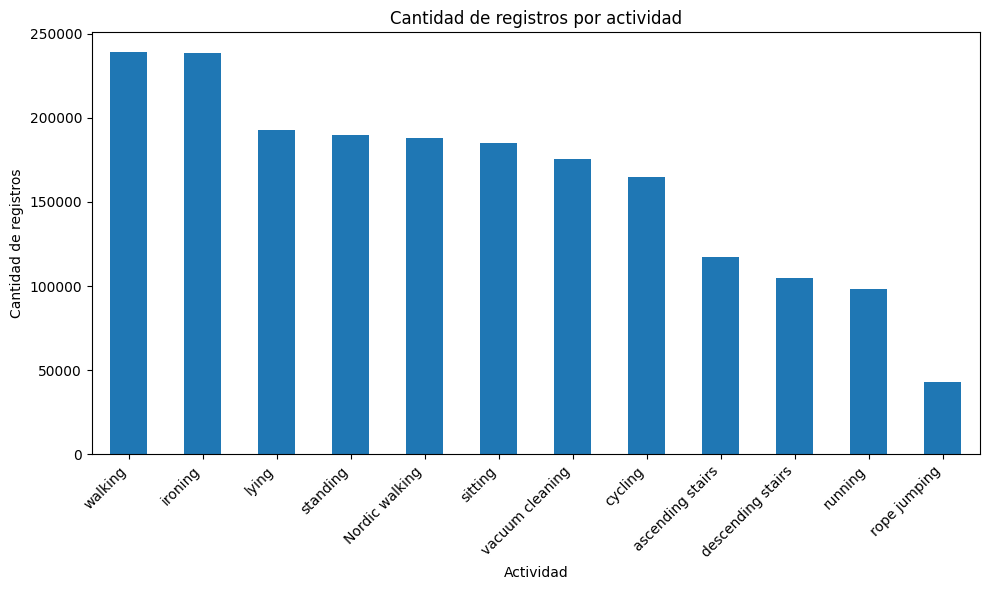

In [29]:
import matplotlib.pyplot as plt

conteo = df["activityID"].value_counts()

plt.figure(figsize=(10, 6))
conteo.plot(kind="bar")

plt.title("Cantidad de registros por actividad")
plt.xlabel("Actividad")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()